In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from time import perf_counter

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    ExtraTreesClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.svm import SVC

from sklearn.model_selection import ParameterSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

import matplotlib.pyplot as plt
from IPython.display import display
import pickle

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None

In [3]:
projectDir = Path.cwd().resolve().parent
dataPath = projectDir / "data" / "processed" / "matchupDiff_week5_features.csv"

matchupDiff = pd.read_csv(dataPath)
matchupDiff["y"] = matchupDiff["y"].astype(int)

# dropping any columns that could cause data leakage
leakCols = [
    "WScore", "LScore", "WTeamID", "LTeamID", "winnerTeamId",
    "team1Name", "team2Name", "Unnamed: 0"
]

idCols = ["team1Id", "team2Id"]

dropCols = ["Season", "y"] + leakCols + idCols

# train = 2003 - 2021, validation = 2022, test = 2023 - 2025
trainDf = matchupDiff[matchupDiff["Season"] <= 2021].copy()
valDf   = matchupDiff[matchupDiff["Season"] == 2022].copy()
testDf  = matchupDiff[matchupDiff["Season"].between(2023, 2025)].copy()

def buildXy(splitDf, featureCols=None):
    x = splitDf.drop(columns=dropCols, errors="ignore")
    x = x.select_dtypes(include=[np.number])

    if featureCols is None:
        featureCols = x.columns.tolist()
    else:
        x = x.reindex(columns=featureCols)

    y = splitDf["y"].astype(int)
    return x, y, featureCols

xTrain, yTrain, featureCols = buildXy(trainDf)
xVal, yVal, _ = buildXy(valDf, featureCols)
xTest, yTest, _ = buildXy(testDf, featureCols)

print(f"Train shape: {xTrain.shape}, Val shape: {xVal.shape}, Test shape: {xTest.shape}")
print(f"Positive class rate in train: {yTrain.mean():.3f}")

Train shape: (1162, 108), Val shape: (63, 108), Test shape: (128, 108)
Positive class rate in train: 0.675


In [4]:
thresholds = [0.45, 0.50, 0.55]
randomSeed = 226

def scorePredictions(y, proba, threshold):
    preds = (proba >= threshold).astype(int)
    metrics = {
        "accuracy": accuracy_score(y, preds),
        "precision": precision_score(y, preds, zero_division=0),
        "recall": recall_score(y, preds, zero_division=0)
    }
    cm = confusion_matrix(y, preds)
    cmDf = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
    return metrics, cmDf

def buildModel(cfg):

    if cfg["modelFamily"] == "xgboost":
        return XGBClassifier(
            n_estimators=cfg["nEstimators"],
            max_depth=cfg["maxDepth"],
            learning_rate=cfg["learningRate"],
            subsample=cfg["subsample"],
            colsample_bytree=cfg["colsampleBytree"],
            min_child_weight=cfg["minChildWeight"],
            gamma=cfg["gamma"],
            reg_lambda=cfg["regLambda"],
            reg_alpha=cfg["regAlpha"],
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=cfg["randomState"],
            n_jobs=-1,
            tree_method="hist"
        )

    if cfg["modelFamily"] == "catboost":
        return CatBoostClassifier(
            iterations=cfg["iterations"],
            depth=cfg["depth"],
            learning_rate=cfg["learningRate"],
            l2_leaf_reg=cfg["l2LeafReg"],
            random_strength=cfg["randomStrength"],
            bagging_temperature=cfg["baggingTemperature"],
            border_count=cfg["borderCount"],
            loss_function="Logloss",
            eval_metric="Accuracy",
            verbose=0,
            allow_writing_files=False,
            random_seed=cfg["randomState"],
            thread_count=-1
        )

    if cfg["modelFamily"] == "histGradientBoosting":
        return HistGradientBoostingClassifier(
            learning_rate=cfg["learningRate"],
            max_depth=cfg["maxDepth"],
            max_leaf_nodes=cfg["maxLeafNodes"],
            min_samples_leaf=cfg["minSamplesLeaf"],
            l2_regularization=cfg["l2Regularization"],
            max_iter=cfg["maxIter"],
            random_state=cfg["randomState"]
        )

    if cfg["modelFamily"] == "extraTrees":
        return ExtraTreesClassifier(
            n_estimators=cfg["nEstimators"],
            max_depth=cfg["maxDepth"],
            min_samples_split=cfg["minSamplesSplit"],
            min_samples_leaf=cfg["minSamplesLeaf"],
            max_features=cfg["maxFeatures"],
            bootstrap=cfg["bootstrap"],
            class_weight=cfg["classWeight"],
            random_state=cfg["randomState"],
            n_jobs=-1
        )

    if cfg["modelFamily"] == "randomForest":
        return RandomForestClassifier(
            n_estimators=cfg["nEstimators"],
            max_depth=cfg["maxDepth"],
            min_samples_split=cfg["minSamplesSplit"],
            min_samples_leaf=cfg["minSamplesLeaf"],
            max_features=cfg["maxFeatures"],
            bootstrap=cfg["bootstrap"],
            class_weight=cfg["classWeight"],
            random_state=cfg["randomState"],
            n_jobs=-1
        )

    if cfg["modelFamily"] == "gradientBoosting":
        return GradientBoostingClassifier(
            n_estimators=cfg["nEstimators"],
            learning_rate=cfg["learningRate"],
            subsample=cfg["subsample"],
            min_samples_split=cfg["minSamplesSplit"],
            min_samples_leaf=cfg["minSamplesLeaf"],
            max_depth=cfg["maxDepth"],
            random_state=cfg["randomState"]
        )

    if cfg["modelFamily"] == "adaBoost":
        return AdaBoostClassifier(
            n_estimators=cfg["nEstimators"],
            learning_rate=cfg["learningRate"],
            random_state=cfg["randomState"]
        )

    if cfg["modelFamily"] == "mlp":
        return MLPClassifier(
            hidden_layer_sizes=cfg["hiddenLayerSizes"],
            alpha=cfg["alpha"],
            learning_rate_init=cfg["learningRateInit"],
            max_iter=cfg["maxIter"],
            early_stopping=cfg["earlyStopping"],
            random_state=cfg["randomState"]
        )

    if cfg["modelFamily"] == "svc":
        return SVC(
            C=cfg["cValue"],
            gamma=cfg["gamma"],
            kernel=cfg["kernel"],
            probability=True,
            random_state=cfg["randomState"]
        )

    raise ValueError(f"Unsupported model family: {cfg['modelFamily']}")

def buildPipeline(cfg):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if cfg["scaleFeatures"]:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", buildModel(cfg)))
    return Pipeline(steps=steps)

def displayConfig(cfg):
    return {k: v for k, v in cfg.items() if k not in ["scaleFeatures"]}

def normalizeValue(value):
    if isinstance(value, dict):
        return tuple((k, normalizeValue(v)) for k, v in sorted(value.items()))
    if isinstance(value, list):
        return tuple(normalizeValue(v) for v in value)
    if isinstance(value, tuple):
        return tuple(normalizeValue(v) for v in value)
    return value

def configSignature(cfg):
    signature = []
    for key, value in sorted(cfg.items()):
        signature.append((key, normalizeValue(value)))
    return tuple(signature)

def gridSize(grid):
    size = 1
    for values in grid.values():
        size *= len(values)
    return size

def sampleConfigs(modelFamily, grid, nIter, scaleFeatures, seedOffset):
    actualIter = min(nIter, gridSize(grid))
    sampled = list(ParameterSampler(grid, n_iter=actualIter, random_state=randomSeed + seedOffset))
    return [
        {
            "modelFamily": modelFamily,
            "scaleFeatures": scaleFeatures,
            "randomState": randomSeed,
            **cfg,
        }
        for cfg in sampled
    ]

In [5]:
configs = []
seenConfigs = set()
searchPlan = []

# XGBoost
if XGBClassifier is not None:
    xgbGrid = {
        "nEstimators": [200, 400, 600, 800, 1000],
        "maxDepth": [3, 4, 5, 6, 8],
        "learningRate": [0.01, 0.03, 0.05, 0.08, 0.10],
        "subsample": [0.7, 0.85, 1.0],
        "colsampleBytree": [0.6, 0.8, 1.0],
        "minChildWeight": [1, 3, 5, 7],
        "gamma": [0.0, 0.1, 0.3],
        "regLambda": [1, 3, 5, 7],
        "regAlpha": [0.0, 0.1, 0.5]
    }
    searchPlan.append(("xgboost", xgbGrid, 60, False, 11))

# CatBoost
if CatBoostClassifier is not None:
    catGrid = {
        "iterations": [300, 500, 700, 900, 1200],
        "depth": [4, 5, 6, 8, 10],
        "learningRate": [0.01, 0.03, 0.05, 0.08, 0.10],
        "l2LeafReg": [1, 3, 5, 7, 9],
        "randomStrength": [0.5, 1.0, 2.0],
        "baggingTemperature": [0.0, 1.0, 3.0],
        "borderCount": [64, 128, 254]
    }
    searchPlan.append(("catboost", catGrid, 60, False, 29))

# HistGradientBoosting
histGrid = {
    "learningRate": [0.01, 0.03, 0.05, 0.08, 0.10],
    "maxDepth": [None, 4, 6, 8, 10],
    "maxLeafNodes": [15, 31, 63, 127],
    "minSamplesLeaf": [5, 10, 20, 30],
    "l2Regularization": [0.0, 0.1, 0.3, 1.0],
    "maxIter": [200, 400, 600, 800]
}
searchPlan.append(("histGradientBoosting", histGrid, 40, False, 43))

# ExtraTrees
extraTreesGrid = {
    "nEstimators": [300, 500, 800, 1000],
    "maxDepth": [None, 10, 20, 30],
    "minSamplesSplit": [2, 5, 10],
    "minSamplesLeaf": [1, 2, 4],
    "maxFeatures": ["sqrt", "log2", 0.5, 0.8],
    "bootstrap": [False, True],
    "classWeight": [None, "balanced", {0: 1, 1: 1.25}, {0: 1, 1: 1.5}]
}
searchPlan.append(("extraTrees", extraTreesGrid, 35, False, 59))

# RandomForest
randomForestGrid = {
    "nEstimators": [300, 500, 800, 1000],
    "maxDepth": [None, 10, 20, 30],
    "minSamplesSplit": [2, 5, 10],
    "minSamplesLeaf": [1, 2, 4],
    "maxFeatures": ["sqrt", "log2", 0.5, 0.8],
    "bootstrap": [False, True],
    "classWeight": [None, "balanced", {0: 1, 1: 1.25}, {0: 1, 1: 1.5}]
}
searchPlan.append(("randomForest", randomForestGrid, 35, False, 71))

# GradientBoosting
gradientBoostingGrid = {
    "nEstimators": [150, 250, 400, 600],
    "learningRate": [0.01, 0.03, 0.05, 0.08, 0.10],
    "subsample": [0.7, 0.85, 1.0],
    "minSamplesSplit": [2, 5, 10],
    "minSamplesLeaf": [1, 2, 4],
    "maxDepth": [2, 3, 4, 5]
}
searchPlan.append(("gradientBoosting", gradientBoostingGrid, 30, False, 83))

# AdaBoost
adaBoostGrid = {
    "nEstimators": [100, 200, 400, 600, 800],
    "learningRate": [0.01, 0.03, 0.05, 0.08, 0.10, 0.20, 0.50, 1.0]
}
searchPlan.append(("adaBoost", adaBoostGrid, 25, False, 97))

# MLP
mlpGrid = {
    "hiddenLayerSizes": [(64, 32), (96, 48), (128, 64), (128, 64, 32), (256, 128, 64)],
    "alpha": [0.00005, 0.0001, 0.0005, 0.001, 0.005],
    "learningRateInit": [0.0001, 0.0003, 0.0005, 0.001, 0.003],
    "maxIter": [1200, 1800, 2500],
    "earlyStopping": [True]
}
searchPlan.append(("mlp", mlpGrid, 30, True, 109))

# SVC
svcGrid = {
    "cValue": [0.1, 0.3, 1.0, 3.0, 10.0, 30.0],
    "gamma": ["scale", 0.001, 0.01, 0.05, 0.10],
    "kernel": ["rbf", "poly", "sigmoid"]
}
searchPlan.append(("svc", svcGrid, 25, True, 127))


for modelFamily, grid, nIter, scaleFeatures, seedOffset in searchPlan:
    for cfg in sampleConfigs(modelFamily, grid, nIter, scaleFeatures, seedOffset):
        signature = configSignature(cfg)
        if signature not in seenConfigs:
            seenConfigs.add(signature)
            configs.append(cfg)

searchPlanDf = pd.DataFrame(
    [
        {
            "modelFamily": modelFamily,
            "sampledConfigs": min(nIter, gridSize(grid)),
            "rawGridSize": gridSize(grid)
        }
        for modelFamily, grid, nIter, scaleFeatures, seedOffset in searchPlan
    ]
)

print(f"Total sampled model fits: {len(configs)}")
print(f"Thresholds tested per fit: {thresholds}")
display(searchPlanDf)

Total sampled model fits: 280
Thresholds tested per fit: [0.45, 0.5, 0.55]


,modelFamily,sampledConfigs,rawGridSize
0,xgboost,60,162000
1,histGradientBoosting,40,6400
2,extraTrees,35,4608
3,randomForest,35,4608
4,gradientBoosting,30,2160
5,adaBoost,25,40
6,mlp,30,375
7,svc,25,90


In [6]:
results = []
failedConfigs = []
configLookup = {}

overallStart = perf_counter()

for idx, cfg in enumerate(configs):
    configLookup[idx] = cfg

    try:
        pipe = buildPipeline(cfg)

        fitStart = perf_counter()
        pipe.fit(xTrain, yTrain)
        fitSeconds = perf_counter() - fitStart

        trainProba = pipe.predict_proba(xTrain)[:, 1]
        valProba   = pipe.predict_proba(xVal)[:, 1]

        for threshold in thresholds:
            trainMetrics, _ = scorePredictions(yTrain, trainProba, threshold)
            valMetrics, _   = scorePredictions(yVal, valProba, threshold)

            results.append({
                "configId": idx,
                "modelFamily": cfg["modelFamily"],
                "threshold": threshold,
                "fitSeconds": fitSeconds,
                "model": str(displayConfig(cfg)),
                "set": "train",
                **trainMetrics
            })

            results.append({
                "configId": idx,
                "modelFamily": cfg["modelFamily"],
                "threshold": threshold,
                "fitSeconds": fitSeconds,
                "model": str(displayConfig(cfg)),
                "set": "val",
                **valMetrics
            })

        if (idx + 1) % 20 == 0:
            elapsedMinutes = (perf_counter() - overallStart) / 60
            print(f"Completed {idx + 1}/{len(configs)} fits in {elapsedMinutes:.1f} minutes", flush=True)

    except Exception as err:
        failedConfigs.append({
            "configId": idx,
            "modelFamily": cfg["modelFamily"],
            "model": str(displayConfig(cfg)),
            "error": str(err)
        })


resultsDf = pd.DataFrame(results)

resultsDf = resultsDf.sort_values(
    ["set", "accuracy", "recall", "precision"],
    ascending=[True, False, False, False]
)

if failedConfigs:
    display(pd.DataFrame(failedConfigs))

print(f"Successful fits: {resultsDf['configId'].nunique()}")
print(f"Failed fits: {len(failedConfigs)}")
print(f"Total elapsed minutes: {(perf_counter() - overallStart) / 60:.1f}")

display(resultsDf.head(12))

Completed 20/280 fits in 0.9 minutes
Completed 40/280 fits in 2.1 minutes
Completed 60/280 fits in 3.2 minutes
Completed 80/280 fits in 5.2 minutes
Completed 100/280 fits in 6.3 minutes
Completed 120/280 fits in 7.3 minutes
Completed 140/280 fits in 9.2 minutes
Completed 160/280 fits in 12.8 minutes
Completed 180/280 fits in 17.4 minutes
Completed 200/280 fits in 21.2 minutes


/Users/ashererickson/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/ashererickson/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/ashererickson/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/ashererickson/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. U

Completed 220/280 fits in 23.7 minutes


/Users/ashererickson/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/ashererickson/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/ashererickson/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/ashererickson/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. U

Completed 240/280 fits in 24.3 minutes
Completed 260/280 fits in 24.5 minutes
Completed 280/280 fits in 24.8 minutes
Successful fits: 280
Failed fits: 0
Total elapsed minutes: 24.8


,configId,modelFamily,threshold,fitSeconds,model,set,accuracy,precision,recall
0,0,xgboost,0.45,2.811881,"{'modelFamily': 'xgboost', 'randomState': 226,...",train,1.0,1.0,1.0
2,0,xgboost,0.50,2.811881,"{'modelFamily': 'xgboost', 'randomState': 226,...",train,1.0,1.0,1.0
4,0,xgboost,0.55,2.811881,"{'modelFamily': 'xgboost', 'randomState': 226,...",train,1.0,1.0,1.0
12,2,xgboost,0.45,1.124575,"{'modelFamily': 'xgboost', 'randomState': 226,...",train,1.0,1.0,1.0
14,2,xgboost,0.50,1.124575,"{'modelFamily': 'xgboost', 'randomState': 226,...",train,1.0,1.0,1.0
16,2,xgboost,0.55,1.124575,"{'modelFamily': 'xgboost', 'randomState': 226,...",train,1.0,1.0,1.0
24,4,xgboost,0.45,3.095509,"{'modelFamily': 'xgboost', 'randomState': 226,...",train,1.0,1.0,1.0
26,4,xgboost,0.50,3.095509,"{'modelFamily': 'xgboost', 'randomState': 226,...",train,1.0,1.0,1.0
28,4,xgboost,0.55,3.095509,"{'modelFamily': 'xgboost', 'randomState': 226,...",train,1.0,1.0,1.0
36,6,xgboost,0.45,3.273795,"{'modelFamily': 'xgboost', 'randomState': 226,...",train,1.0,1.0,1.0


In [7]:
valOnly = resultsDf[resultsDf["set"] == "val"].copy()
valOnly = valOnly.sort_values(["accuracy", "recall", "precision"], ascending=False)

familySummary = valOnly.groupby("modelFamily").agg(
    bestAccuracy=("accuracy", "max"),
    avgAccuracy=("accuracy", "mean"),
    bestRecall=("recall", "max"),
    avgFitSeconds=("fitSeconds", "mean"),
    testedThresholds=("threshold", "nunique"),
    testedConfigs=("configId", "nunique")
).sort_values(["bestAccuracy", "bestRecall"], ascending=False)

print("MODEL FAMILY VALIDATION SUMMARY:")
display(familySummary)

print("TOP 15 VALIDATION RESULTS:")
display(valOnly.head(15))

MODEL FAMILY VALIDATION SUMMARY:


,bestAccuracy,avgAccuracy,bestRecall,avgFitSeconds,testedThresholds,testedConfigs
modelFamily,,,,,,
adaBoost,0.809524,0.615238,1.0,6.739589,3,25
gradientBoosting,0.809524,0.733862,1.0,11.424645,3,30
histGradientBoosting,0.809524,0.761376,1.0,4.557957,3,40
xgboost,0.809524,0.763492,1.0,3.117799,3,60
mlp,0.793651,0.662610,1.0,0.432512,3,30
randomForest,0.793651,0.721995,1.0,12.524689,3,35
extraTrees,0.777778,0.716402,1.0,2.499412,3,35
svc,0.730159,0.644444,1.0,0.605147,3,25


TOP 15 VALIDATION RESULTS:


,configId,modelFamily,threshold,fitSeconds,model,set,accuracy,precision,recall
109,18,xgboost,0.45,2.455389,"{'modelFamily': 'xgboost', 'randomState': 226,...",val,0.809524,0.780000,0.975
1221,203,adaBoost,0.50,12.364145,"{'modelFamily': 'adaBoost', 'randomState': 226...",val,0.809524,0.780000,0.975
1143,190,gradientBoosting,0.50,3.919394,"{'modelFamily': 'gradientBoosting', 'randomSta...",val,0.809524,0.791667,0.950
433,72,histGradientBoosting,0.45,2.899487,"{'modelFamily': 'histGradientBoosting', 'rando...",val,0.809524,0.804348,0.925
435,72,histGradientBoosting,0.50,2.899487,"{'modelFamily': 'histGradientBoosting', 'rando...",val,0.809524,0.804348,0.925
241,40,xgboost,0.45,4.963790,"{'modelFamily': 'xgboost', 'randomState': 226,...",val,0.793651,0.754717,1.000
21,3,xgboost,0.50,0.883886,"{'modelFamily': 'xgboost', 'randomState': 226,...",val,0.793651,0.764706,0.975
79,13,xgboost,0.45,2.130788,"{'modelFamily': 'xgboost', 'randomState': 226,...",val,0.793651,0.764706,0.975
1045,174,gradientBoosting,0.45,6.155652,"{'modelFamily': 'gradientBoosting', 'randomSta...",val,0.793651,0.764706,0.975
1287,214,adaBoost,0.50,6.633896,"{'modelFamily': 'adaBoost', 'randomState': 226...",val,0.793651,0.764706,0.975


In [8]:
bestRow = valOnly.iloc[0]
bestCfg = configLookup[int(bestRow["configId"])].copy()
bestCfg["threshold"] = float(bestRow["threshold"])

print("WINNING MODEL (BEST VALIDATION PERFORMANCE):")
print(bestRow)
print(displayConfig(bestCfg))

WINNING MODEL (BEST VALIDATION PERFORMANCE):
configId                                                      18
modelFamily                                              xgboost
threshold                                                   0.45
fitSeconds                                              2.455389
model          {'modelFamily': 'xgboost', 'randomState': 226,...
set                                                          val
accuracy                                                0.809524
precision                                                   0.78
recall                                                     0.975
Name: 109, dtype: object
{'modelFamily': 'xgboost', 'randomState': 226, 'subsample': 0.85, 'regLambda': 1, 'regAlpha': 0.1, 'nEstimators': 600, 'minChildWeight': 7, 'maxDepth': 4, 'learningRate': 0.01, 'gamma': 0.1, 'colsampleBytree': 0.8, 'threshold': 0.45}


In [9]:
bestPipe = buildPipeline(bestCfg)
bestPipe.fit(xTrain, yTrain)

trainProba = bestPipe.predict_proba(xTrain)[:, 1]
valProba   = bestPipe.predict_proba(xVal)[:, 1]

trainMetrics, trainCm = scorePredictions(yTrain, trainProba, bestCfg["threshold"])
valMetrics, valCm     = scorePredictions(yVal, valProba, bestCfg["threshold"])

print("Train metrics:", trainMetrics)
display(trainCm)

print("Validation metrics:", valMetrics)
display(valCm)

# Fit on Train+Val before final Test
trainValDf = matchupDiff[matchupDiff["Season"] <= 2022].copy()
xTrainVal, yTrainVal, _ = buildXy(trainValDf, featureCols)

bestPipe.fit(xTrainVal, yTrainVal)

testProba = bestPipe.predict_proba(xTest)[:, 1]
testMetrics, testCm = scorePredictions(yTest, testProba, bestCfg["threshold"])

print("Test metrics (2023-2025):", testMetrics)
display(testCm)

Train metrics: {'accuracy': 0.9165232358003442, 'precision': 0.894374282433984, 'recall': 0.9936224489795918}


,Pred 0,Pred 1
Actual 0,286,92
Actual 1,5,779


Validation metrics: {'accuracy': 0.8095238095238095, 'precision': 0.78, 'recall': 0.975}


,Pred 0,Pred 1
Actual 0,12,11
Actual 1,1,39


Test metrics (2023-2025): {'accuracy': 0.6953125, 'precision': 0.7090909090909091, 'recall': 0.9176470588235294}


,Pred 0,Pred 1
Actual 0,11,32
Actual 1,7,78


In [10]:
winningModelMetricsDf = pd.DataFrame([
    {"dataset": "train", **trainMetrics},
    {"dataset": "validation", **valMetrics},
    {"dataset": "test", **testMetrics}
])

print("WINNING MODEL PERFORMANCE SUMMARY TABLE:")
display(winningModelMetricsDf)

WINNING MODEL PERFORMANCE SUMMARY TABLE:


,dataset,accuracy,precision,recall
0,train,0.916523,0.894374,0.993622
1,validation,0.809524,0.780000,0.975000
2,test,0.695312,0.709091,0.917647


,modelFamily,accuracy,valError,configId,threshold,trainError
0,adaBoost,0.809524,0.190476,203,0.50,0.002582
1,randomForest,0.793651,0.206349,137,0.50,0.005164
2,extraTrees,0.777778,0.222222,119,0.55,0.002582
3,gradientBoosting,0.809524,0.190476,190,0.50,0.108434
4,histGradientBoosting,0.809524,0.190476,72,0.45,0.000000
5,svc,0.730159,0.269841,265,0.55,0.112737
6,mlp,0.793651,0.206349,227,0.50,0.048193
7,xgboost,0.809524,0.190476,18,0.45,0.083477


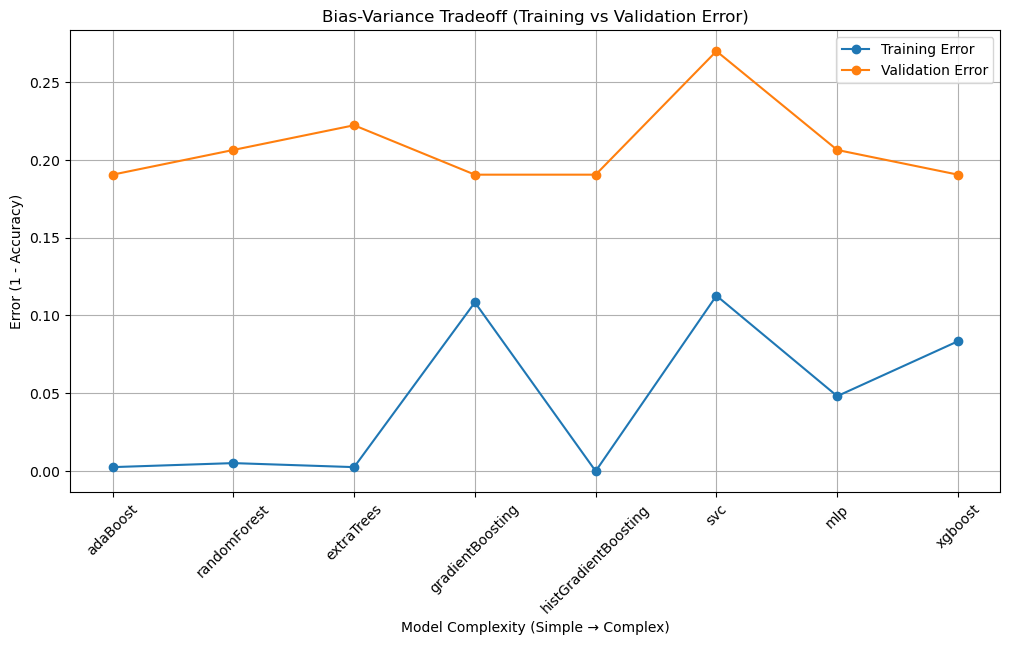

In [11]:
# Choose best validation result PER MODEL FAMILY
bestPerFamily = valOnly.sort_values(["accuracy", "recall", "precision"], ascending=False)\
                       .groupby("modelFamily")\
                       .head(1)\
                       .copy()

# Complexity order (simple -> complex)
modelOrder = [
    "adaBoost",
    "randomForest",
    "extraTrees",
    "gradientBoosting",
    "histGradientBoosting",
    "svc",
    "mlp",
    "xgboost",
    "catboost"
]

bestPerFamily["modelFamily"] = pd.Categorical(bestPerFamily["modelFamily"], categories=modelOrder, ordered=True)
bestPerFamily = bestPerFamily.sort_values("modelFamily")

# Pull matching TRAIN rows for same configId/threshold
trainOnly = resultsDf[resultsDf["set"] == "train"].copy()

trainMatches = trainOnly.merge(
    bestPerFamily[["configId", "threshold", "modelFamily"]],
    on=["configId", "threshold", "modelFamily"],
    how="inner"
)

# Add error columns
bestPerFamily["valError"] = 1 - bestPerFamily["accuracy"]
trainMatches["trainError"] = 1 - trainMatches["accuracy"]

biasVarianceDf = bestPerFamily[["modelFamily", "accuracy", "valError", "configId", "threshold"]].copy()
biasVarianceDf = biasVarianceDf.merge(
    trainMatches[["modelFamily", "trainError"]],
    on="modelFamily",
    how="left"
)

display(biasVarianceDf)

# Plot
plt.figure(figsize=(12,6))
plt.plot(biasVarianceDf["modelFamily"], biasVarianceDf["trainError"], marker="o", label="Training Error")
plt.plot(biasVarianceDf["modelFamily"], biasVarianceDf["valError"], marker="o", label="Validation Error")

plt.title("Bias-Variance Tradeoff (Training vs Validation Error)")
plt.xlabel("Model Complexity (Simple → Complex)")
plt.ylabel("Error (1 - Accuracy)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [12]:
modelDir = projectDir / "models"
modelDir.mkdir(parents=True, exist_ok=True)

modelPath = modelDir / "week9_best_model.pkl"

payload = {
    "model": bestPipe,
    "modelFamily": bestCfg["modelFamily"],
    "threshold": bestCfg["threshold"],
    "featureCols": featureCols,
    "params": displayConfig(bestCfg),
    "trainMetrics": trainMetrics,
    "validationMetrics": valMetrics,
    "testMetrics": testMetrics
}

with open(modelPath, "wb") as f:
    pickle.dump(payload, f)


processedDir = projectDir / "data" / "processed"
processedDir.mkdir(parents=True, exist_ok=True)

allResultsCsvPath = processedDir / "week9_all_model_results.csv"
familySummaryCsvPath = processedDir / "week9_family_summary.csv"
winningModelMetricsPath = processedDir / "week9_winning_model_metrics.csv"
biasVarianceCsvPath = processedDir / "week9_bias_variance_data.csv"

resultsDf.to_csv(allResultsCsvPath, index=False)
familySummary.reset_index().to_csv(familySummaryCsvPath, index=False)
winningModelMetricsDf.to_csv(winningModelMetricsPath, index=False)
biasVarianceDf.to_csv(biasVarianceCsvPath, index=False)

print(f"Saved model to: {modelPath}")
print(f"Saved all model results to: {allResultsCsvPath}")
print(f"Saved family summary to: {familySummaryCsvPath}")
print(f"Saved winning model metrics table to: {winningModelMetricsPath}")
print(f"Saved bias variance chart data to: {biasVarianceCsvPath}")

Saved model to: /Users/ashererickson/models/week9_best_model.pkl
Saved all model results to: /Users/ashererickson/data/processed/week9_all_model_results.csv
Saved family summary to: /Users/ashererickson/data/processed/week9_family_summary.csv
Saved winning model metrics table to: /Users/ashererickson/data/processed/week9_winning_model_metrics.csv
Saved bias variance chart data to: /Users/ashererickson/data/processed/week9_bias_variance_data.csv
